# 🫀 ecgGAN Pipeline v2 (Improved) — Sintetis EKG Class AMI

**Perubahan dari v1:**
- Window 4 detik (bukan 10s penuh) → GAN lebih mudah belajar pola beat
- Data training di-augment via windowing: 353 → ~1000+ windows
- Epoch 1500, LR lebih kecil, n_critic=3 → training lebih stabil
- Rendering: stitch window + crossfade → beat lebih kontinu

**Pipeline:**
1. Load sinyal AMI dari PTB-XL → windowing (4s, stride 2s)
2. Train BiLSTM-CNN GAN (WGAN-GP) — 1500 epochs
3. Generate window → stitch jadi 10s → potong 10 segmen → PNG

## 📦 Install

In [1]:
!pip install -q wfdb

In [2]:
!pip install --upgrade pip

In [3]:
!pip install numpy==1.26.4 pandas --force-reinstall -q

## 📚 Imports

In [4]:
%matplotlib inline
import os, sys, json, random, warnings, glob
import numpy as np
import pandas as pd
import ast
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import wfdb

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3090


## ⚙️ Konfigurasi (Improved)

In [5]:
# ========== SESUAIKAN PATH ==========
PTBXL_PATH = "/workspace/data/ptb-xl"
OUTPUT_DIR = "/workspace/ecg_gan_ami_v2"
CLASS_NAME = "AMI"

# ========== IMPROVED HYPERPARAMETERS ==========
# Windowing
WINDOW_SEC = 4              # Train pada 4 detik (bukan 10s)
WINDOW_STRIDE_SEC = 2       # Overlap 2 detik → lebih banyak data

# GAN Training
EPOCHS = 1500               # Naik dari 500
BATCH_SIZE = 64             # Naik dari 32
LATENT_DIM = 100
LR_GEN = 0.0001            # Turun dari 0.0002
LR_DISC = 0.00005          # Turun dari 0.0001
N_CRITIC = 3                # Naik dari 2
GP_LAMBDA = 10.0
SAVE_INTERVAL = 100

# BiLSTM (sesuai paper ecgGAN)
BILSTM_UNITS = 128
BILSTM_LAYERS = 2
DROPOUT = 0.3

# Output
N_EKG_FULL = 100            # 100 EKG × 10 segmen = 1000 PNG
N_SEGMENTS = 10

# PNG (sesuai segmen asli)
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF',
              'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
SEG_WIDTH = 390
SEG_HEIGHT = 989
PNG_DPI = 100
LINE_WIDTH = 0.8

# ==========================================
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print("⚙️ KONFIGURASI v2 (IMPROVED)")
print("="*60)
print(f"   Window          : {WINDOW_SEC}s (stride {WINDOW_STRIDE_SEC}s)")
print(f"   Epochs          : {EPOCHS}")
print(f"   Batch Size      : {BATCH_SIZE}")
print(f"   LR Gen/Disc     : {LR_GEN} / {LR_DISC}")
print(f"   n_critic        : {N_CRITIC}")
print(f"   Output          : {N_EKG_FULL} EKG × {N_SEGMENTS} seg = {N_EKG_FULL * N_SEGMENTS} PNG")
print("="*60)

⚙️ KONFIGURASI v2 (IMPROVED)
   Window          : 4s (stride 2s)
   Epochs          : 1500
   Batch Size      : 64
   LR Gen/Disc     : 0.0001 / 5e-05
   n_critic        : 3
   Output          : 100 EKG × 10 seg = 1000 PNG


## 🔵 STEP 1: Load Sinyal AMI + Windowing

Sinyal 10 detik dipotong jadi window 4 detik (stride 2s).  
353 sinyal → ~1000+ training windows → GAN punya lebih banyak data untuk belajar.

In [6]:
# === STEP 1: LOAD + WINDOW ===

print(f"\n{'='*65}")
print(f"  STEP 1: LOAD + WINDOW SINYAL AMI")
print(f"{'='*65}")

csv_path = os.path.join(PTBXL_PATH, "ptbxl_database.csv")
assert os.path.exists(csv_path), f"❌ File tidak ditemukan: {csv_path}"

df = pd.read_csv(csv_path, index_col='ecg_id')
df['scp_codes_parsed'] = df['scp_codes'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

ami_records = df[df['scp_codes_parsed'].apply(
    lambda codes: 'AMI' in codes if isinstance(codes, dict) else False
)]

SAMPLING_RATE = 100
FILENAME_COL = 'filename_lr'
FULL_SEQ_LEN = SAMPLING_RATE * 10  # 1000

print(f"  📊 AMI records: {len(ami_records)}")
print(f"  🔄 Loading sinyal...")

full_signals = []
failed = 0

for idx, row in ami_records.iterrows():
    try:
        record_path = os.path.join(PTBXL_PATH, row[FILENAME_COL])
        if not os.path.exists(record_path + '.hea'):
            alt = os.path.join(PTBXL_PATH, row[FILENAME_COL].split("/", 1)[-1])
            if os.path.exists(alt + '.hea'):
                record_path = alt
            else:
                record_path = os.path.join(PTBXL_PATH, "records100",
                                           row[FILENAME_COL].split("/", 1)[-1])

        record = wfdb.rdrecord(record_path)
        sig = record.p_signal.T[:12, :FULL_SEQ_LEN]

        if sig.shape[1] < FULL_SEQ_LEN:
            sig = np.hstack([sig, np.zeros((12, FULL_SEQ_LEN - sig.shape[1]))])

        full_signals.append(sig)
    except:
        failed += 1

print(f"  ✅ Loaded {len(full_signals)} full signals ({failed} failed)")

# === WINDOWING ===
window_samples = WINDOW_SEC * SAMPLING_RATE        # 400
stride_samples = WINDOW_STRIDE_SEC * SAMPLING_RATE  # 200

windowed = []
for sig in full_signals:
    start = 0
    while start + window_samples <= sig.shape[1]:
        window = sig[:, start:start + window_samples]
        windowed.append(window)
        start += stride_samples

data = np.array(windowed, dtype=np.float32)
data = np.nan_to_num(data, nan=0.0)
SEQ_LEN = window_samples  # 400

print(f"  📊 Windowed: {len(full_signals)} signals → {data.shape[0]} windows")
print(f"  📊 Shape: {data.shape} ({WINDOW_SEC}s per window)")

# Normalisasi
scaler = {}
for lead in range(data.shape[1]):
    vmin = float(np.nanmin(data[:, lead, :]))
    vmax = float(np.nanmax(data[:, lead, :]))
    scaler[lead] = {'min': vmin, 'max': vmax}
    rng = vmax - vmin
    if rng > 1e-8:
        data[:, lead, :] = 2.0 * (data[:, lead, :] - vmin) / rng - 1.0
    else:
        data[:, lead, :] = 0.0

with open(f"{OUTPUT_DIR}/scaler.json", 'w') as f:
    json.dump({str(k): v for k, v in scaler.items()}, f, indent=2)

print(f"  ✅ Training data ready: {data.shape}")


  STEP 1: LOAD + WINDOW SINYAL AMI
  📊 AMI records: 353
  🔄 Loading sinyal...
  ✅ Loaded 353 full signals (0 failed)
  📊 Windowed: 353 signals → 1412 windows
  📊 Shape: (1412, 12, 400) (4s per window)
  ✅ Training data ready: (1412, 12, 400)


## 🟣 STEP 2: Arsitektur BiLSTM-CNN GAN

Identik dengan ecgGAN (Zhu et al. 2019), tapi sekarang untuk window 4 detik.

In [7]:
# === ARSITEKTUR ===

class BiLSTMGenerator(nn.Module):
    def __init__(self, latent_dim, n_leads, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.init_len = seq_len // 8

        self.fc_in = nn.Sequential(
            nn.Linear(latent_dim, self.init_len * 64),
            nn.LeakyReLU(0.2)
        )
        self.bilstm = nn.LSTM(
            input_size=64, hidden_size=BILSTM_UNITS,
            num_layers=BILSTM_LAYERS, batch_first=True,
            bidirectional=True, dropout=DROPOUT
        )
        self.drop = nn.Dropout(DROPOUT)
        bilstm_out = BILSTM_UNITS * 2

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(bilstm_out, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128), nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(128, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv1d(32, n_leads, kernel_size=7, padding=3),
            nn.Tanh()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, z):
        batch = z.size(0)
        x = self.fc_in(z).view(batch, self.init_len, 64)
        x, _ = self.bilstm(x)
        x = self.drop(x).permute(0, 2, 1)
        x = self.upsample(x)
        if x.size(2) >= self.seq_len:
            x = x[:, :, :self.seq_len]
        else:
            x = nn.functional.pad(x, (0, self.seq_len - x.size(2)))
        return x


class CNNDiscriminator(nn.Module):
    def __init__(self, n_leads, seq_len):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_leads, 64, 5, padding=2), nn.LeakyReLU(0.2, True), nn.AvgPool1d(4, 4),
            nn.Conv1d(64, 128, 5, padding=2), nn.LeakyReLU(0.2, True), nn.AvgPool1d(4, 4),
            nn.Conv1d(128, 256, 3, padding=1), nn.LeakyReLU(0.2, True), nn.AvgPool1d(2, 2),
            nn.Conv1d(256, 256, 3, padding=1), nn.LeakyReLU(0.2, True), nn.AvgPool1d(2, 2),
        )
        with torch.no_grad():
            flat = self.features(torch.zeros(1, n_leads, seq_len)).view(1, -1).size(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(flat, 128),
            nn.LeakyReLU(0.2), nn.Dropout(0.3), nn.Linear(128, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))


def gradient_penalty(disc, real, fake):
    bs = real.size(0)
    alpha = torch.rand(bs, 1, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_out = disc(interp)
    grads = torch.autograd.grad(outputs=d_out, inputs=interp,
        grad_outputs=torch.ones_like(d_out), create_graph=True, retain_graph=True)[0]
    return ((grads.view(bs, -1).norm(2, dim=1) - 1) ** 2).mean()


generator = BiLSTMGenerator(LATENT_DIM, N_LEADS, SEQ_LEN).to(device)
discriminator = CNNDiscriminator(N_LEADS, SEQ_LEN).to(device)

g_p = sum(p.numel() for p in generator.parameters())
d_p = sum(p.numel() for p in discriminator.parameters())
print(f"✅ Models (seq_len={SEQ_LEN}):")
print(f"   Generator:     {g_p:,}")
print(f"   Discriminator: {d_p:,}")

✅ Models (seq_len=400):
   Generator:     1,217,452
   Discriminator: 537,281


### 🏋️ Training (1500 epochs)

In [8]:
# === TRAINING ===

tensor_data = torch.FloatTensor(data).to(device)
loader = DataLoader(TensorDataset(tensor_data),
                    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

opt_g = optim.Adam(generator.parameters(), lr=LR_GEN, betas=(0.5, 0.999))
opt_d = optim.Adam(discriminator.parameters(), lr=LR_DISC, betas=(0.5, 0.999))
sch_g = optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=EPOCHS, eta_min=1e-6)
sch_d = optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=EPOCHS, eta_min=1e-6)

fixed_z = torch.randn(4, LATENT_DIM, device=device)
os.makedirs(f"{OUTPUT_DIR}/progress", exist_ok=True)

history = {'d_loss': [], 'g_loss': [], 'w_dist': [], 'gp': []}
start = datetime.now()

print(f"{'='*65}")
print(f"  STEP 2: TRAINING ecgGAN")
print(f"{'='*65}")
print(f"  {EPOCHS} epochs, {len(loader)} batches/epoch")
print(f"\n  🏋️ Training mulai...\n")

for epoch in range(1, EPOCHS + 1):
    ep_d, ep_g, ep_w, ep_gp, nb = 0, 0, 0, 0, 0

    for (real,) in loader:
        bs = real.size(0)
        for _ in range(N_CRITIC):
            discriminator.zero_grad()
            d_real = discriminator(real).mean()
            z = torch.randn(bs, LATENT_DIM, device=device)
            fake = generator(z).detach()
            d_fake = discriminator(fake).mean()
            gp = gradient_penalty(discriminator, real, fake)
            w = d_real - d_fake
            d_loss = -w + GP_LAMBDA * gp
            d_loss.backward()
            opt_d.step()

        generator.zero_grad()
        z = torch.randn(bs, LATENT_DIM, device=device)
        g_loss = -discriminator(generator(z)).mean()
        g_loss.backward()
        opt_g.step()

        ep_d += d_loss.item(); ep_g += g_loss.item()
        ep_w += w.item(); ep_gp += gp.item()
        nb += 1

    sch_g.step(); sch_d.step()
    for k, v in [('d_loss', ep_d), ('g_loss', ep_g), ('w_dist', ep_w), ('gp', ep_gp)]:
        history[k].append(v / max(nb, 1))

    if epoch % 50 == 0 or epoch == 1:
        el = datetime.now() - start
        print(f"  Epoch [{epoch:5d}/{EPOCHS}]  "
              f"D:{history['d_loss'][-1]:+.4f}  "
              f"G:{history['g_loss'][-1]:+.4f}  "
              f"W:{history['w_dist'][-1]:.4f}  "
              f"GP:{history['gp'][-1]:.4f}  [{el}]")

    if epoch % SAVE_INTERVAL == 0 or epoch == 1:
        generator.eval()
        with torch.no_grad():
            samp = generator(fixed_z).cpu().numpy()
        generator.train()
        fig, ax = plt.subplots(figsize=(12, 3))
        for lead in range(3):
            ax.plot(samp[0, lead, :] + lead*2, lw=0.4, label=LEAD_NAMES[lead])
        ax.legend(fontsize=7); ax.set_title(f'Epoch {epoch}'); ax.axis('off')
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/progress/epoch_{epoch:04d}.png", dpi=80)
        plt.close()

total_time = datetime.now() - start
print(f"\n  ✅ Training selesai! Waktu: {total_time}")

torch.save({
    'generator': generator.state_dict(),
    'discriminator': discriminator.state_dict(),
    'config': {
        'latent_dim': LATENT_DIM, 'n_leads': N_LEADS, 'seq_len': SEQ_LEN,
        'sampling_rate': SAMPLING_RATE, 'bilstm_units': BILSTM_UNITS,
        'bilstm_layers': BILSTM_LAYERS, 'dropout': DROPOUT,
        'window_sec': WINDOW_SEC,
    },
    'history': history,
}, f"{OUTPUT_DIR}/ecg_gan_model.pth")
print(f"  💾 Model: {OUTPUT_DIR}/ecg_gan_model.pth")

  STEP 2: TRAINING ecgGAN
  1500 epochs, 22 batches/epoch

  🏋️ Training mulai...

  Epoch [    1/1500]  D:+8.5765  G:-1.0834  W:-0.0463  GP:0.8530  [0:00:02.252366]
  Epoch [   50/1500]  D:+0.2405  G:+4.5011  W:-0.1382  GP:0.0102  [0:01:21.539366]
  Epoch [  100/1500]  D:+2.4173  G:-1.2560  W:1.8251  GP:0.4242  [0:02:42.367619]
  Epoch [  150/1500]  D:+0.3376  G:-13.8947  W:0.0825  GP:0.0420  [0:04:01.878532]
  Epoch [  200/1500]  D:+0.1420  G:+6.6134  W:-0.0450  GP:0.0097  [0:05:22.314227]
  Epoch [  250/1500]  D:-0.2210  G:+16.7536  W:0.9356  GP:0.0715  [0:06:43.227905]
  Epoch [  300/1500]  D:-0.2471  G:+26.9430  W:0.2990  GP:0.0052  [0:08:03.415632]
  Epoch [  350/1500]  D:-0.2502  G:+28.1523  W:0.3074  GP:0.0057  [0:09:22.774228]
  Epoch [  400/1500]  D:-0.2871  G:+31.7039  W:0.3396  GP:0.0053  [0:10:42.694858]
  Epoch [  450/1500]  D:-0.2849  G:+34.5949  W:0.3482  GP:0.0063  [0:12:01.437005]
  Epoch [  500/1500]  D:-0.3813  G:+28.3634  W:0.4538  GP:0.0073  [0:13:14.896471]
  Epo

### 📊 Training Curves

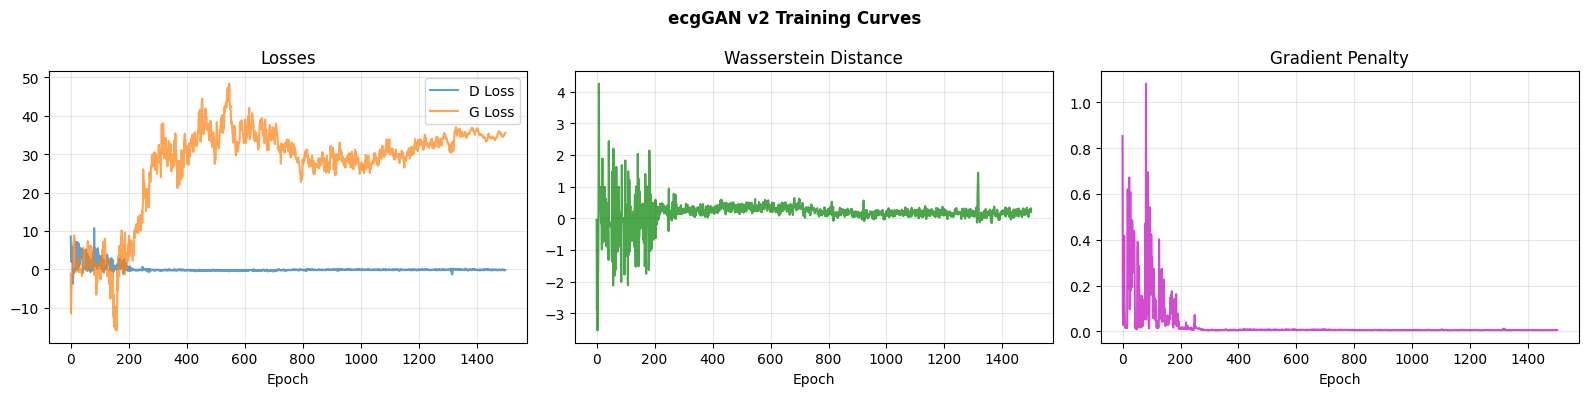

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['d_loss'], alpha=0.7, label='D Loss')
axes[0].plot(history['g_loss'], alpha=0.7, label='G Loss')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Losses'); axes[0].set_xlabel('Epoch')
axes[1].plot(history['w_dist'], 'g-', alpha=0.7)
axes[1].set_title('Wasserstein Distance'); axes[1].grid(alpha=0.3); axes[1].set_xlabel('Epoch')
axes[2].plot(history['gp'], 'm-', alpha=0.7)
axes[2].set_title('Gradient Penalty'); axes[2].grid(alpha=0.3); axes[2].set_xlabel('Epoch')
plt.suptitle('ecgGAN v2 Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

## 🟡 STEP 3+4: Generate → Stitch → Segment → PNG

Generate window 4 detik → gabung (crossfade) jadi 10 detik → potong 10 segmen → render PNG.

In [10]:
# === HELPER FUNCTIONS ===

def denormalize_signal(sig, scaler):
    result = sig.copy()
    for lead in range(min(sig.shape[0], len(scaler))):
        s = scaler[lead]
        result[lead, :] = (sig[lead, :] + 1) / 2 * (s['max'] - s['min']) + s['min']
    return result

def stitch_windows(windows, overlap_samples):
    if len(windows) == 1:
        return windows[0]
    n_leads = windows[0].shape[0]
    win_len = windows[0].shape[1]
    total = win_len + (len(windows) - 1) * (win_len - overlap_samples)
    result = np.zeros((n_leads, total))
    pos = 0
    for i, win in enumerate(windows):
        if i == 0:
            result[:, :win_len] = win
        else:
            fade_in = np.linspace(0, 1, overlap_samples)
            fade_out = np.linspace(1, 0, overlap_samples)
            result[:, pos:pos+overlap_samples] = (
                result[:, pos:pos+overlap_samples] * fade_out +
                win[:, :overlap_samples] * fade_in
            )
            result[:, pos+overlap_samples:pos+win_len] = win[:, overlap_samples:]
        pos += win_len - overlap_samples
    return result

def render_segment_png(signal_12lead, save_path):
    n_leads = signal_12lead.shape[0]
    fig_w = SEG_WIDTH / PNG_DPI
    fig_h = SEG_HEIGHT / PNG_DPI
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=PNG_DPI, facecolor='white')
    gs = gridspec.GridSpec(n_leads, 1, hspace=0.05,
                           left=0.15, right=0.98, top=0.98, bottom=0.02)
    for i in range(n_leads):
        ax = fig.add_subplot(gs[i, 0])
        sig = signal_12lead[i, :]
        smin, smax = sig.min(), sig.max()
        if smax - smin > 1e-8:
            sig_norm = (sig - smin) / (smax - smin)
        else:
            sig_norm = np.zeros_like(sig) + 0.5
        x = np.linspace(0, 1, len(sig_norm))
        ax.plot(x, sig_norm, color='black', linewidth=LINE_WIDTH, antialiased=True)
        ax.text(-0.10, 0.5, LEAD_NAMES[i], transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='center', ha='right')
        ax.set_xlim(0, 1); ax.set_ylim(-0.1, 1.1); ax.axis('off')
    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
    fig.savefig(save_path, dpi=PNG_DPI, facecolor='white', bbox_inches=None, pad_inches=0)
    plt.close(fig)

print("✅ Helper functions ready")

✅ Helper functions ready


In [11]:
# === GENERATE + STITCH + SEGMENT + RENDER ===

print(f"\n{'='*65}")
print(f"  STEP 3+4: GENERATE → STITCH → SEGMENT → PNG")
print(f"{'='*65}")

generator.eval()
windows_per_full = 10 // WINDOW_SEC + 1  # 3 windows per 10s EKG
full_seq_len = SAMPLING_RATE * 10         # 1000
overlap = SAMPLING_RATE * 1               # 1s overlap

out_dir = os.path.join(OUTPUT_DIR, "synthetic_png", CLASS_NAME)
os.makedirs(out_dir, exist_ok=True)

seg_samples = full_seq_len // N_SEGMENTS
total_rendered = 0

print(f"  Method: {windows_per_full} windows of {WINDOW_SEC}s → stitch → cut {N_SEGMENTS} seg")
print(f"  Target: {N_EKG_FULL} EKG × {N_SEGMENTS} seg = {N_EKG_FULL * N_SEGMENTS} PNG")
print(f"  🔄 Generating...\n")

with torch.no_grad():
    for ekg_idx in range(N_EKG_FULL):
        z = torch.randn(windows_per_full, LATENT_DIM, device=device)
        windows_raw = generator(z).cpu().numpy()

        windows_denorm = [denormalize_signal(w, scaler) for w in windows_raw]
        full_signal = stitch_windows(windows_denorm, overlap)

        if full_signal.shape[1] >= full_seq_len:
            full_signal = full_signal[:, :full_seq_len]
        else:
            full_signal = np.hstack([full_signal,
                np.zeros((12, full_seq_len - full_signal.shape[1]))])

        ecg_id = ekg_idx + 1
        ecg_folder = os.path.join(out_dir, f"synthetic_{ecg_id:05d}")
        os.makedirs(ecg_folder, exist_ok=True)

        for seg_idx in range(N_SEGMENTS):
            start = seg_idx * seg_samples
            end = start + seg_samples
            segment = full_signal[:, start:end]

            png_path = os.path.join(ecg_folder, f"syn_{ecg_id:05d}_seg{seg_idx:02d}.png")
            render_segment_png(segment, png_path)

            try:
                img = Image.open(png_path)
                if img.size != (SEG_WIDTH, SEG_HEIGHT):
                    img = img.resize((SEG_WIDTH, SEG_HEIGHT), Image.BICUBIC)
                    img.save(png_path)
            except:
                pass
            total_rendered += 1

        if ecg_id % 20 == 0 or ecg_id == 1:
            print(f"     EKG [{ecg_id:4d}/{N_EKG_FULL}] → {N_SEGMENTS} seg (total: {total_rendered})")

print(f"\n  ✅ {total_rendered} PNG segmen disimpan di: {out_dir}")


  STEP 3+4: GENERATE → STITCH → SEGMENT → PNG
  Method: 3 windows of 4s → stitch → cut 10 seg
  Target: 100 EKG × 10 seg = 1000 PNG
  🔄 Generating...

     EKG [   1/100] → 10 seg (total: 10)
     EKG [  20/100] → 10 seg (total: 200)
     EKG [  40/100] → 10 seg (total: 400)
     EKG [  60/100] → 10 seg (total: 600)
     EKG [  80/100] → 10 seg (total: 800)
     EKG [ 100/100] → 10 seg (total: 1000)

  ✅ 1000 PNG segmen disimpan di: /workspace/ecg_gan_ami_v2/synthetic_png/AMI


### 📊 Perbandingan Real vs Synthetic

Asli:     1790 PNG
Sintetis: 1000 PNG

🔵 REAL AMI:


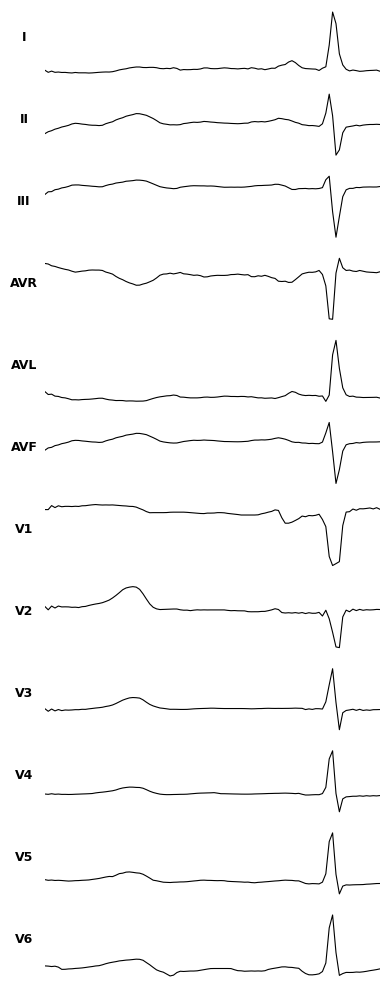


🔴 SYNTHETIC AMI:


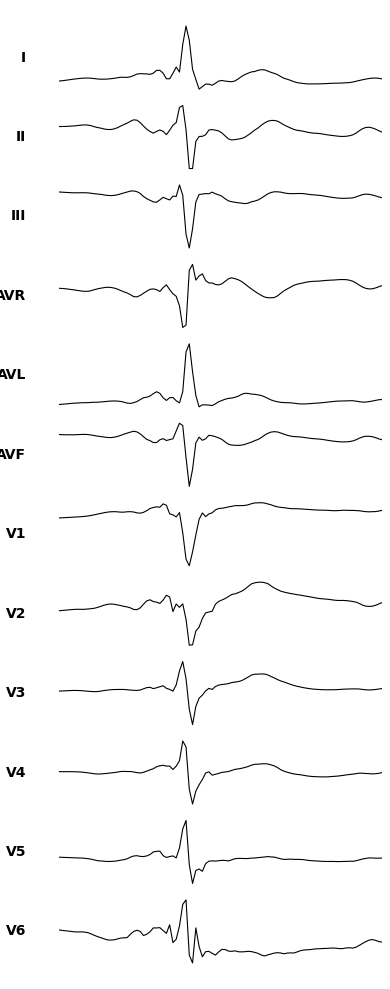

In [12]:
from IPython.display import display, Image as IPImage

synth_dir = os.path.join(OUTPUT_DIR, "synthetic_png", CLASS_NAME)
real_dir = "/workspace/data/png_segments/AMI"

synth_pngs = sorted(glob.glob(f"{synth_dir}/**/*.png", recursive=True))
real_pngs = sorted(glob.glob(f"{real_dir}/**/*.png", recursive=True))

print(f"Asli:     {len(real_pngs)} PNG")
print(f"Sintetis: {len(synth_pngs)} PNG")

print("\n🔵 REAL AMI:")
display(IPImage(filename=random.choice(real_pngs), width=350))

print("\n🔴 SYNTHETIC AMI:")
display(IPImage(filename=random.choice(synth_pngs), width=350))

### 👀 Preview Beberapa Sample

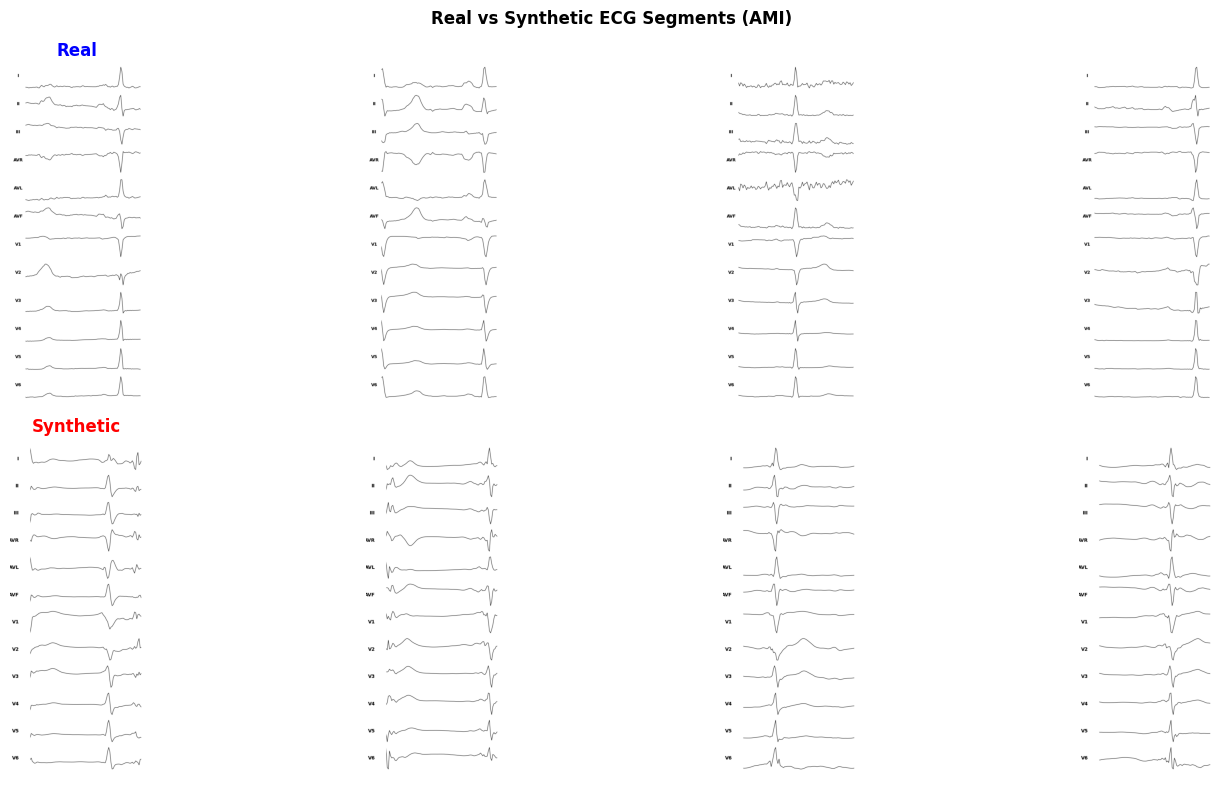

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    rimg = Image.open(random.choice(real_pngs))
    axes[0][i].imshow(rimg); axes[0][i].axis('off')
    axes[0][i].set_title('Real' if i == 0 else '', color='blue', fontweight='bold')

    simg = Image.open(random.choice(synth_pngs))
    axes[1][i].imshow(simg); axes[1][i].axis('off')
    axes[1][i].set_title('Synthetic' if i == 0 else '', color='red', fontweight='bold')

plt.suptitle('Real vs Synthetic ECG Segments (AMI)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/real_vs_synthetic.png", dpi=150)
plt.show()

## 🎉 Summary

In [14]:
total_png = sum(1 for _ in glob.glob(f"{out_dir}/**/*.png", recursive=True))

print(f"""
{'='*65}
🎉 ecgGAN v2 PIPELINE SELESAI!
{'='*65}

📊 Ringkasan:
   Data training     : {len(full_signals)} sinyal → {data.shape[0]} windows ({WINDOW_SEC}s)
   Epochs            : {EPOCHS}
   Sinyal sintetis   : {N_EKG_FULL} × 10 detik
   Total PNG segmen  : {total_png}
   Ukuran PNG        : {SEG_WIDTH}×{SEG_HEIGHT} px

📁 Output: {OUTPUT_DIR}/
   └── synthetic_png/{CLASS_NAME}/ ({total_png} files)

⚠️  Data sintetis HANYA untuk TRAINING ViT!
    Data asli tetap untuk TESTING.
{'='*65}
""")


🎉 ecgGAN v2 PIPELINE SELESAI!

📊 Ringkasan:
   Data training     : 353 sinyal → 1412 windows (4s)
   Epochs            : 1500
   Sinyal sintetis   : 100 × 10 detik
   Total PNG segmen  : 1000
   Ukuran PNG        : 390×989 px

📁 Output: /workspace/ecg_gan_ami_v2/
   └── synthetic_png/AMI/ (1000 files)

⚠️  Data sintetis HANYA untuk TRAINING ViT!
    Data asli tetap untuk TESTING.



## 📋 Cara Integrasi dengan ViT_2.ipynb

Copy kode ini ke **Cell 8** (setelah data collection yang sudah ada):

In [15]:
# === PASTE KE Cell 8 di ViT_2.ipynb (setelah loop data asli) ===

#SYNTH_DIR = f"{OUTPUT_DIR}/synthetic_png/{CLASS_NAME}"
#synth_count = 0

#for ecg_folder in sorted(os.listdir(SYNTH_DIR)):
    ep = os.path.join(SYNTH_DIR, ecg_folder)
    if os.path.isdir(ep):
        #for f in sorted(os.listdir(ep)):
            if f.endswith('.png'):
                data.append({
                    'image_path': os.path.join(ep, f),
                    'label': CLASS_NAME,
                    'label_idx': CLASS_TO_IDX[CLASS_NAME],
                    'ecg_id': ecg_folder,
                    'source': 'synthetic'
                })
                synth_count += 1

print(f"✅ Added {synth_count} synthetic {CLASS_NAME} segments")
print(f"\n⚠️  Di Cell 9 (split), tambahkan:")
print("   df.loc[df['source'] == 'synthetic', 'split'] = 'train'")

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [16]:
from PIL import Image
import numpy as np, glob

synth_pngs = sorted(glob.glob(f"{OUTPUT_DIR}/synthetic_png/{CLASS_NAME}/**/*.png", recursive=True))

flat_count = 0
good_count = 0

for p in synth_pngs:
    img = np.array(Image.open(p).convert('L'))
    # Hitung variasi pixel — flat images punya variasi rendah
    dark_pixels = (img < 128).sum()
    if dark_pixels < 500:  # Hampir tidak ada sinyal
        flat_count += 1
    else:
        good_count += 1

print(f"Total: {len(synth_pngs)}")
print(f"✅ Good (ada beat): {good_count} ({good_count/len(synth_pngs)*100:.0f}%)")
print(f"❌ Flat (garis lurus): {flat_count} ({flat_count/len(synth_pngs)*100:.0f}%)")

Total: 1000
✅ Good (ada beat): 1000 (100%)
❌ Flat (garis lurus): 0 (0%)
